# Understanding Joint distributions and Marginal Distributions

## Overall Goal

The overall goal of this notebook its to very intuitivley understand how marginal distributions are derived from joint distributions.

### 1) Contruct a generic joint distribution of a genric normal bivariate distribution

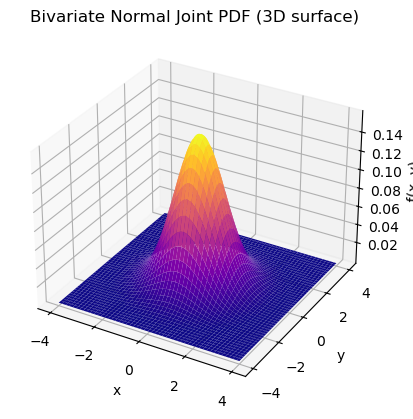

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Parameters ----
mu = np.array([0.0, 0.0])  # mean vector [mu_x, mu_y]

Sigma = np.array([
    [1.0, 0],   # covariance matrix
    [0, 1.0]
])

# ---- Make a grid over (x, y) ----
x = np.linspace(-4, 4, 200)
y = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(x, y) ## -> turns X and Y into an array of coordinates

pos = np.dstack((X, Y))  # shape (200, 200, 2) ## this is a giant list of coordinates

# ---- Bivariate normal PDF ----
from scipy.stats import multivariate_normal

## Im going to make another notebook on distributions so for now we are using a built in function for this
rv = multivariate_normal(mean=mu, cov=Sigma)

Z = rv.pdf(pos)

# ---- Plot 3D surface: (x, y, f(x,y)) ----
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, cmap="plasma", linewidth=0, antialiased=True)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")
ax.set_title("Bivariate Normal Joint PDF (3D surface)")

plt.show()


### 2) Look at slices of the 3d plot

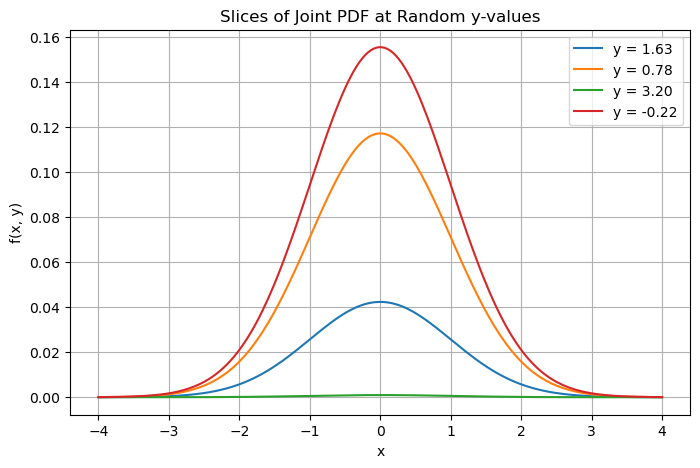

In [38]:
# ---- Pick 4 random y-slices ----

np.random.seed(94857)

indices = np.random.choice(len(y), size=4, replace=False)

# ---- Plot ----
plt.figure(figsize=(8, 5))

for i in indices:
    x_slice = X[i, :]# all x at fixed y
    z_slice = Z[i, :]# pdf values at that y
    y_value = y[i]

    plt.plot(x_slice, z_slice, label=f"y = {y_value:.2f}")

plt.xlabel("x")
plt.ylabel("f(x, y)")
plt.title("Slices of Joint PDF at Random y-values")
plt.legend()
plt.grid(True)
plt.show()

For each of these y values, there exists a slice of x at that point. The **Marginal Distribution** is the sum of all the probabilities at this slice. So let's do that now

### 3) Marginal distribution at the y values

In [65]:

# print(indices)

marginal_distributions_of_y = []

dx = x[1] - x[0] # this is how spaces out the points are

for i in indices: # you are summing over all the x values at a specfic y
    x_slice = X[i, :]# all x at fixed y
    z_slice = Z[i, :]# pdf values at that y
    y_value = y[i]
    
    marginal_distribution_y = 0
    
    for value in z_slice:
        marginal_distribution_y += value * dx

    marginal_distributions_of_y.append([y_value,marginal_distribution_y,i])



In [66]:
marginal_distributions_of_x

for i in marginal_distributions_of_y:
    print(f"For the y value {i[0]} the sum of all the probabilies is {i[1]} at index {i[2]}")
    



For the y value 1.6281407035175883 the sum of all the probabilies is 0.10598923817953054 at index 140
For the y value 0.78391959798995 the sum of all the probabilies is 0.2933873265115262 at index 119
For the y value 3.1959798994974875 the sum of all the probabilies is 0.002414796162013973 at index 179
For the y value -0.22110552763819102 the sum of all the probabilies is 0.3892862018106899 at index 94


Now lets do it for all the y values not just these four:

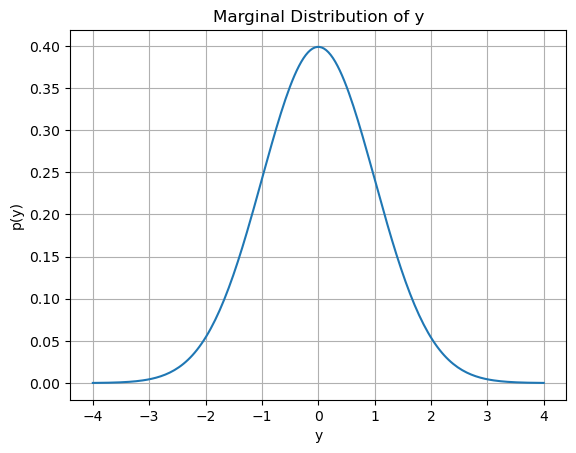

In [68]:
# Marginal of Y from joint PDF Z(x,y)

import numpy as np
import matplotlib.pyplot as plt

# instead of a for loop we can use the sum function
marginal_y = np.sum(Z, axis=0) * dy   # sum over y

# Plot marginal of Y
plt.figure()
plt.plot(y, marginal_y)
plt.xlabel("y")
plt.ylabel("p(y)")
plt.title("Marginal Distribution of y")
plt.grid(True)
plt.show()
